## The functional and object-oriented APIs

earthkit-plots offers two complementary ways to produce plots. Both give you access to the same underlying machinery, but they make different trade-offs between convenience and control.

The **functional API** — accessed through namespaces like `ekp.geo`, `ekp.timeseries` and `ekp.climatology` — is designed for *convenience*. A single call handles layout, styling, and decoration automatically, making it ideal for exploratory work. Methods on the returned objects are **chainable**, so you can keep building a plot in a single fluent expression.

The **object-oriented (OO) API** — built around `ekp.Map`, `ekp.TimeSeries`, and `ekp.Figure` — gives you explicit control over every element. By default, methods return **real values** rather than `self`, which makes it easy to capture return values, inspect layers, and integrate with the rest of Python. This is the right choice for complex, multi-layer figures and production output.

This notebook works through both levels using the same datasets, so you can see clearly what each one does for you, and when you might prefer one over the other.

Let's start by getting some sample data.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

# ERA5 monthly averaged 2-metre temperature for December 1993
era5_2t = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")

# An ECMWF HRES forecast containing mean sea-level pressure and wind gusts
joachim = ekd.from_source(
    "url",
    "https://get.ecmwf.int/repository/test-data/metview/gallery/fc_msl_wg_joachim.grib",
).to_fieldlist()

# An ERA5 hourly 2m-temperature time series at a point location
era5_reading_timeseries = ekd.from_source("sample", "era5-reading-timeseries.nc").to_xarray()

---

## The functional API

### Namespaces

The functional API is organised into namespaces, each grouping shortcuts for a particular type of plot:

- **`ekp.geo`** — geographic map plots (`plot`, `contourf`, `contour`, `pcolormesh`, `quiver`, `spaghetti`, …)
- **`ekp.timeseries`** — time series plots (`line`, `bar`, `scatter`, `fill_between`, `multiboxplot`, …)
- **`ekp.climatology`** — annual-cycle plots (`line`, `bar`, `scatter`, `fill_between`)

### Geographic plots

The simplest way to plot a gridded field on a map is `ekp.geo.plot`:

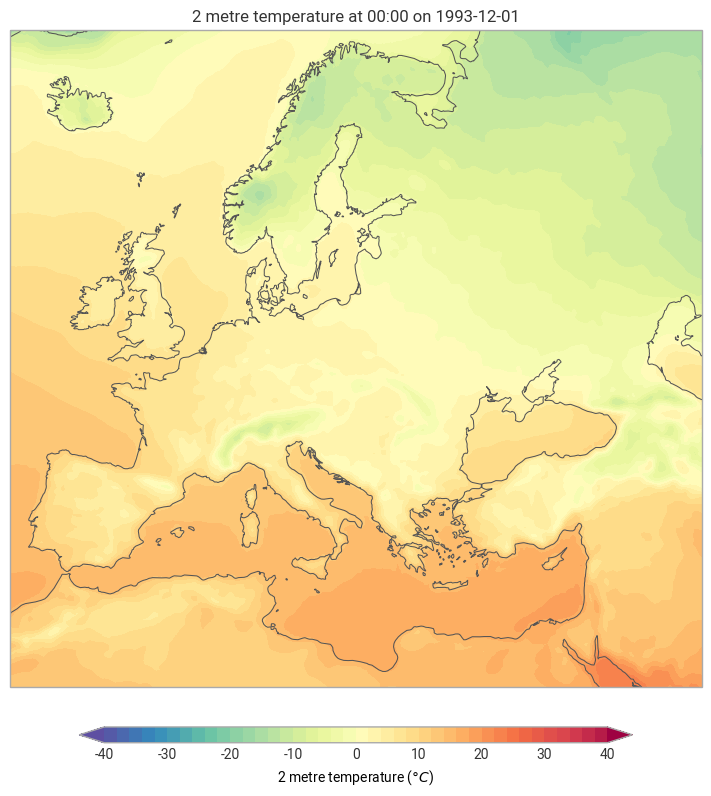

In [2]:
ekp.geo.plot(era5_2t, domain="Europe", units="celsius")

One line of code, and earthkit-plots has automatically:

- Created a `Figure` and a geographic `Map` subplot covering the `"Europe"` domain.
- Selected an appropriate plot method for the data (`contourf` for a gridded scalar field).
- Applied unit conversion from Kelvin to Celsius at plot time, without modifying the source data.
- Chosen a pre-defined colour scheme from the built-in style library based on the variable metadata.
- Added a title, coastlines, and a colour-bar legend.

These three decorations are applied by default on every `ekp.geo` call. You can control each one individually with keyword arguments:

| Argument | Default | Effect |
|---|---|---|
| `title` | `True` | Auto-title from metadata. Pass a string to set a custom title, `False` to suppress. |
| `legend` | `True` | Adds a colour-bar legend. Pass `False` to suppress. |
| `coastlines` | `True` | Overlays coastlines. Pass `False` to suppress. |

### Multi-panel layouts

The functional API handles multi-panel layouts automatically. Pass `groupby` with a metadata key and earthkit-plots splits the data into groups, works out how many panels are needed, and lays them out in a grid — one panel per unique value. For example:

In [3]:
joachim.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,msl,2011-12-15 00:00:00,2011-12-15,0 days 00:00:00,0,surface,0,regular-ll
1,10fg6,2011-12-15 00:00:00,2011-12-15,0 days 00:00:00,0,surface,0,regular-ll
2,msl,2011-12-15 06:00:00,2011-12-15,0 days 06:00:00,0,surface,0,regular-ll
3,10fg6,2011-12-15 06:00:00,2011-12-15,0 days 06:00:00,0,surface,0,regular-ll
4,msl,2011-12-15 12:00:00,2011-12-15,0 days 12:00:00,0,surface,0,regular-ll
5,10fg6,2011-12-15 12:00:00,2011-12-15,0 days 12:00:00,0,surface,0,regular-ll
6,msl,2011-12-15 18:00:00,2011-12-15,0 days 18:00:00,0,surface,0,regular-ll
7,10fg6,2011-12-15 18:00:00,2011-12-15,0 days 18:00:00,0,surface,0,regular-ll
8,msl,2011-12-16 00:00:00,2011-12-15,1 days 00:00:00,0,surface,0,regular-ll
9,10fg6,2011-12-16 00:00:00,2011-12-15,1 days 00:00:00,0,surface,0,regular-ll


We have two fields (wind gust and mean sea-level pressure) at each validity time. We can group these onto subplots like this:

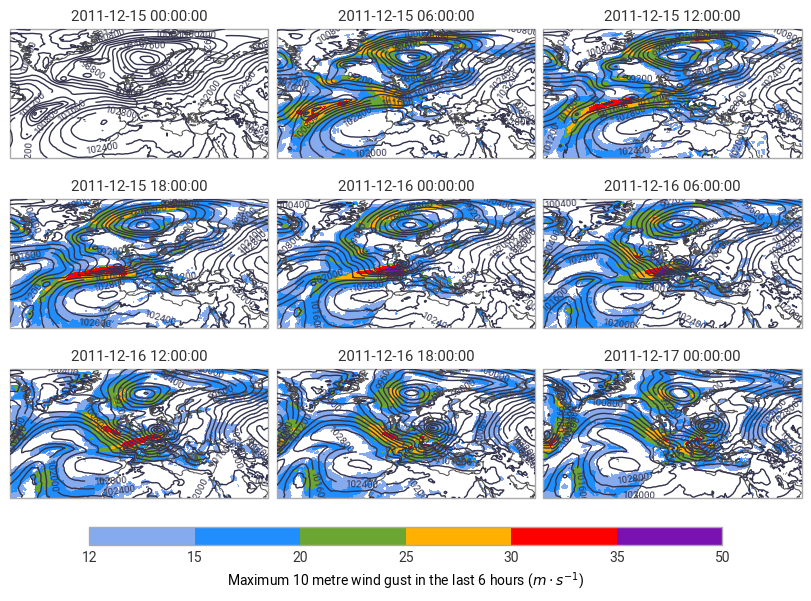

In [4]:
ekp.geo.plot(joachim, groupby="time.valid_datetime", title="{time.valid_datetime}", columns=3, figsize=(8, 6))

Each panel is automatically titled with the value of the groupby key — here the valid date and time. Coastlines and a legend are added to the figure as a whole.

> **Tip:** You can use any metadata key that your data source supports as a `groupby` value — earthkit FieldList components like `"time.step"` or `"vertical.level"`, xarray coordinate names and more.

### Time series plots

The `ekp.timeseries` namespace provides the same convenience for time series data. `ekp.timeseries.line` automatically extracts the time axis, labels the axes, and adds a title:

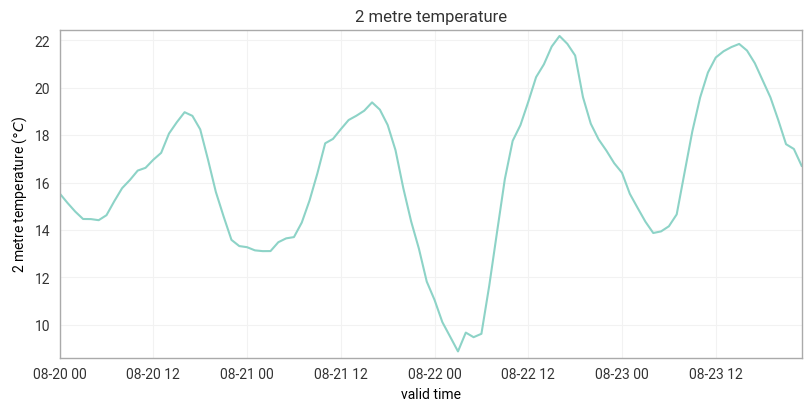

In [5]:
ekp.timeseries.line(era5_reading_timeseries, units="celsius")

The same metadata-aware features available in map plots — unit conversion, format strings in titles and labels — work identically here.

> **Other namespaces:** `ekp.timeseries` also includes `bar`, `scatter`, `fill_between`, `multiboxplot` and `stripes`. The `ekp.climatology` namespace provides most of the same methods for annual-cycle plots, where multiple years of data are folded onto a common Jan–Dec x-axis.

### Chaining on the functional API

Every functional shortcut returns the underlying earthkit-plots object — a `Map` for a single panel, or a `Figure` for multi-panel layouts. Methods on these returned objects are **chainable**: each method returns `self`, so you can keep building the plot in a single expression.

This is useful when you want to suppress a default decoration and replace it with something more specific:

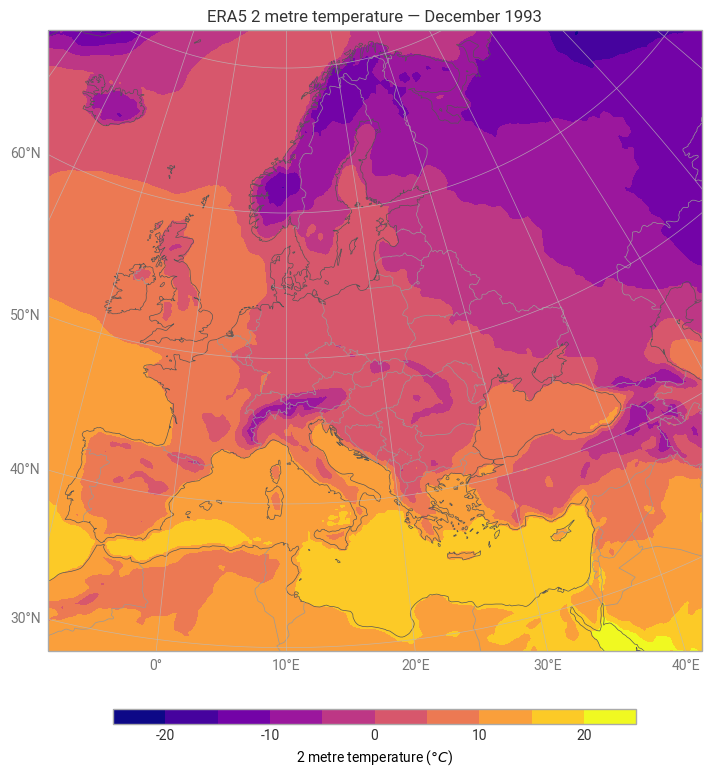

In [6]:
(
    ekp.geo.contourf(
        era5_2t,
        domain="Europe",
        units="celsius",
        title=False,
        coastlines=False,
    )
    .coastlines(linewidth=0.5)
    .borders()
    .gridlines(xstep=10, ystep=10)
    .title("ERA5 {variable_name} — {time:%B %Y}")
    .show()
)

#### When to use the functional API

- You want a quick look at your data with minimal code.
- You are happy with the default decorations, or want to tweak them with `title=`, `legend=`, `coastlines=`.
- You need a multi-panel grid driven by a single metadata dimension.
- You are exploring data interactively in a notebook.

---

## The object-oriented API

The object-oriented API gives you explicit control over every part of a plot. The core classes are:

- **`ekp.Map`** — a geographic subplot backed by a cartopy `GeoAxes`.
- **`ekp.TimeSeries`** — a non-geographic subplot for time series and Cartesian plots.
- **`ekp.Figure`** — the overall canvas; manages the matplotlib `GridSpec` and a collection of subplots.

When you construct `ekp.Map` or `ekp.TimeSeries` directly, **methods return real values** rather than `self`. This makes it easy to capture return values and integrate with raw matplotlib — and it makes the code clear to read, since each statement does exactly one thing.

Here is the same temperature map written with the OO API:

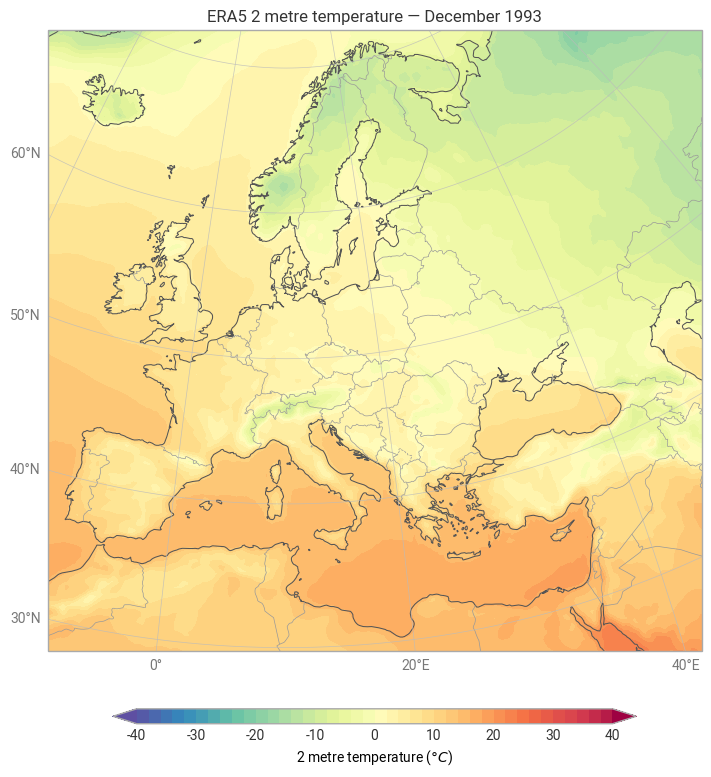

In [7]:
chart = ekp.Map(domain="Europe")

chart.contourf(era5_2t, units="celsius", style="auto")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.title("ERA5 {variable_name} — {time:%B %Y}")
chart.legend(label="{variable_name} ({units})")
chart.show()

Each method is a separate statement. Nothing appears unless you ask for it — that explicitness is the point. You can add exactly what you need, in exactly the order you want.

The OO style also makes it straightforward to build multi-layer plots, since you can call as many plot methods as you like on the same object:

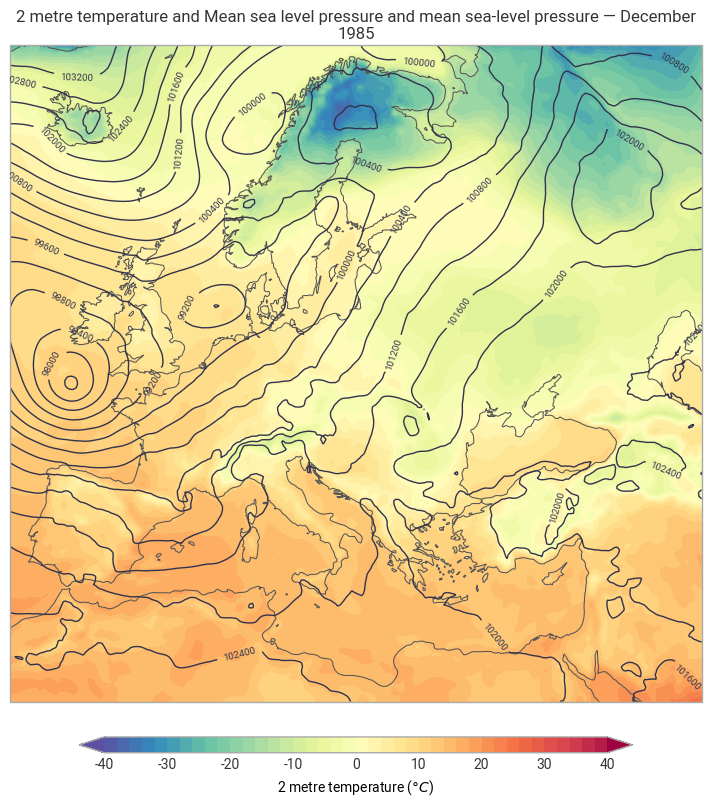

In [8]:
data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
temperature = data.sel({"parameter.variable": "2t"})
pressure = data.sel({"parameter.variable": "msl"})

chart = ekp.Map(domain="Europe")

# Layer 1: filled temperature contours
chart.contourf(temperature, units="celsius", style="auto")

# Layer 2: pressure contour lines on top
chart.contour(pressure, style="auto")

chart.coastlines()
chart.legend()
chart.title("{variable_name} and mean sea-level pressure — {time:%B %Y}")
chart.show()

### Time series with the OO API

`ekp.TimeSeries` works exactly like `ekp.Map` — construct it directly, then call methods on the object:

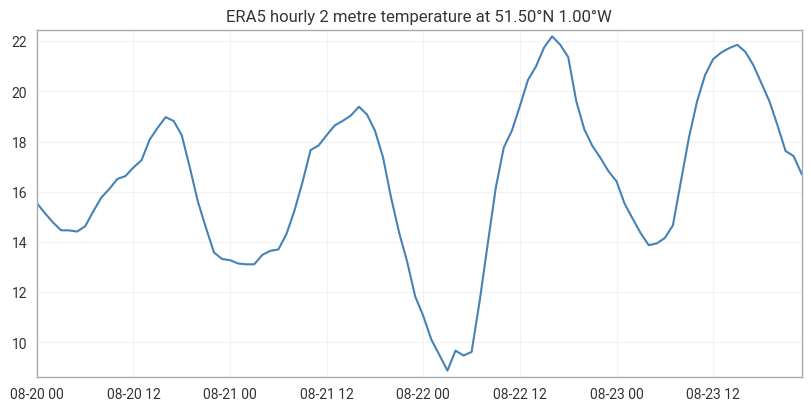

In [9]:
ts = ekp.TimeSeries()

ts.line(era5_reading_timeseries, units="celsius", color="steelblue")
ts.title("ERA5 hourly {variable_name} at {latitude:%Lt} {longitude:%Ln}")
ts.show()

### Dual axes with `twinx`

The OO API exposes a `twinx()` method that creates a second y-axis sharing the same x-axis. The returned object is a fully-fledged earthkit-plots `TimeSeries` (or `Subplot`), so you can call any of the same methods on it:

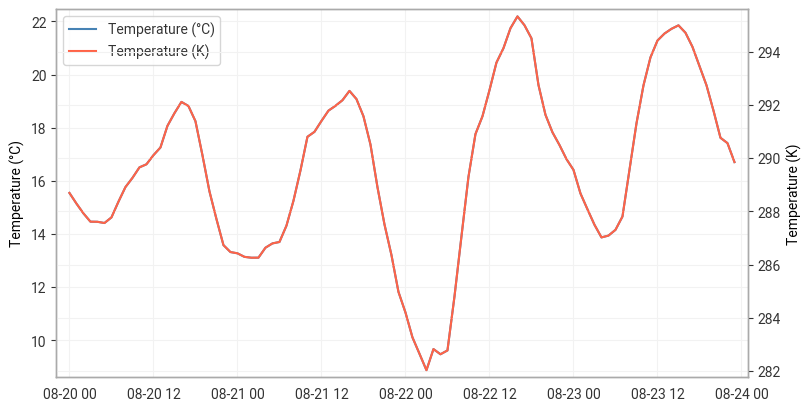

In [10]:
ts = ekp.TimeSeries()
ts.line(era5_reading_timeseries, units="celsius", color="steelblue", label="Temperature (°C)")
ts.ylabel("Temperature (°C)", side="left")

ts_right = ts.twinx()
ts_right.line(era5_reading_timeseries, units="kelvin", color="tomato", label="Temperature (K)")
ts_right.ylabel("Temperature (K)", side="right")

ts.legend()
ts.show()

### Escape hatches: `.ax` and `.fig`

Because earthkit-plots is built on matplotlib, you can drop into raw matplotlib at any point using the `.ax` and `.fig` escape hatches on any subplot or figure object. This means there is no ceiling on what you can produce — if earthkit-plots does not expose a setting directly, matplotlib almost certainly does:

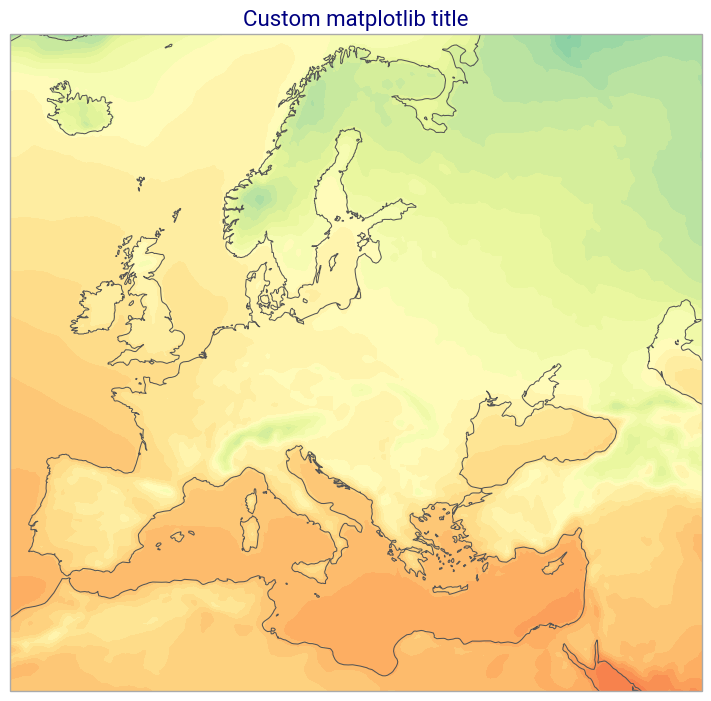

In [11]:
chart = ekp.Map(domain="Europe")
chart.contourf(era5_2t, units="celsius", style="auto")
chart.coastlines()

# Drop into raw matplotlib for anything earthkit-plots doesn't expose directly
chart.ax.set_title("Custom matplotlib title", fontsize=16, color="navy")
chart.show()

#### When to use the OO API

- You need **multiple data layers** on the same panel (e.g. filled contours with wind barbs on top).
- You want **precise control** over which decorations are added and in what order.
- You need a **custom layout** — non-uniform grids, mixed panel types, or panels with different projections.
- You are building a **production figure** where every detail matters.
- You need **dual axes** (`twinx`) or other matplotlib features not available via the functional API.

---

## `Figure` and multi-panel layouts

`ekp.Figure` is the canvas for multi-panel plots. Subplots are added with `fig.add_map()` or `fig.add_subplot()`. Like `ekp.Map` and `ekp.TimeSeries`, a directly-constructed `Figure` is non-chainable by default — methods return real values and each call is a plain statement:

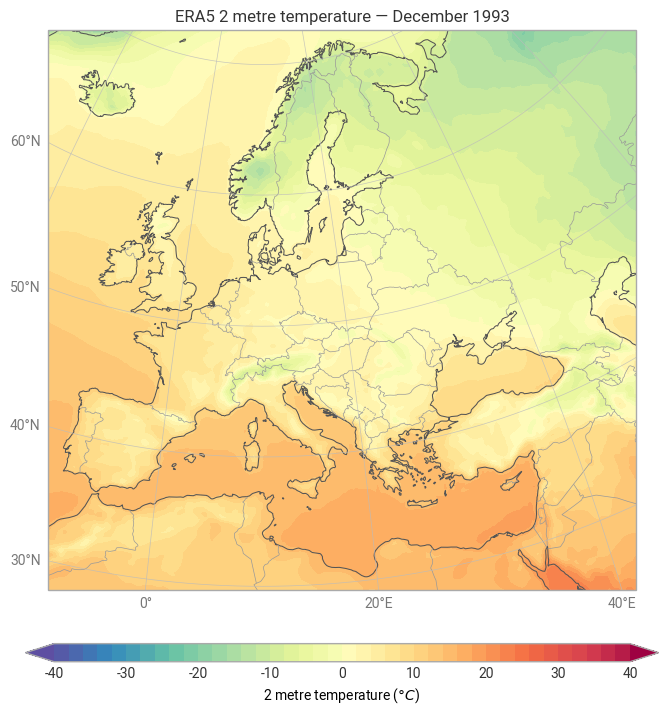

In [12]:
from earthkit.plots import Figure

figure = Figure(rows=1, columns=1)
chart = figure.add_map(domain="Europe")

chart.contourf(era5_2t, units="celsius", style="auto")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.title("ERA5 {variable_name} — {time:%B %Y}")
chart.legend(label="{variable_name} ({units})")
figure.show()

For more on multi-panel layouts with `Figure`, see the [Layouts and Figures](04-layouts.ipynb) notebook.

---

## They are the same underneath

The functional shortcuts are thin wrappers around the OO API. A call like `ekp.geo.plot(data, domain="Europe")` creates a `Figure`, calls `fig.add_map(domain="Europe")`, calls the appropriate plotting method on the map, and runs the figure workflow (coastlines, legend, titles). The object it returns is a fully-fledged `Map`, identical to one you would have created directly:

<class 'earthkit.plots.components.maps.Map'>
<class 'earthkit.plots.components.figures.Figure'>


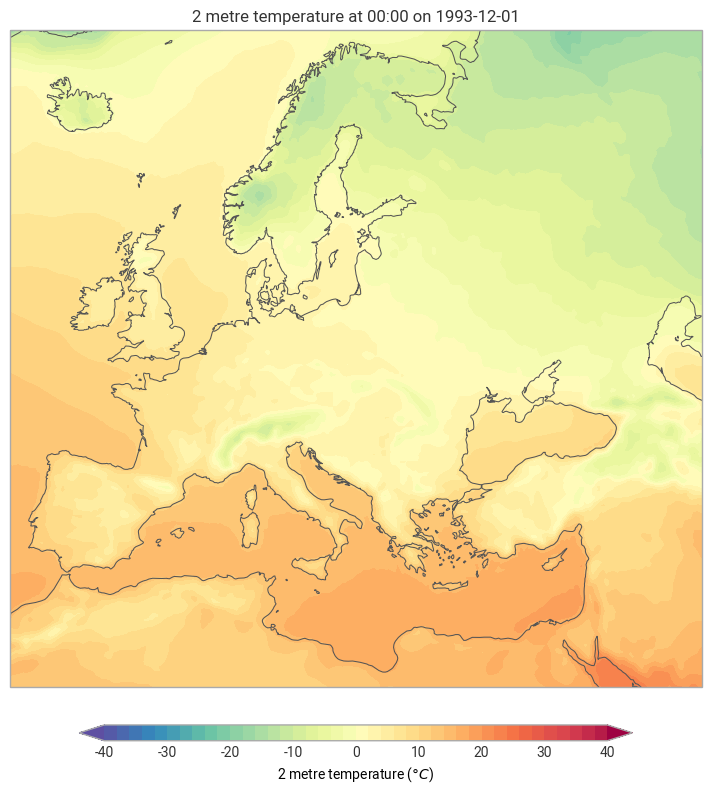

In [13]:
result = ekp.geo.plot(era5_2t, domain="Europe", units="celsius")

print(type(result))         # Map — single panels are unwrapped from the Figure automatically
print(type(result.figure))  # Figure
print(result.layers)        # the Layer objects produced by the contourf call

The two APIs can also be freely mixed. Start with a functional shortcut to get sensible defaults, suppress what you don't want, and then use the OO API to refine:

```python
# Start with the functional API — one line, sensible defaults
chart = ekp.geo.contourf(era5_2t, domain="Europe", units="celsius", title=False, coastlines=False)

# Refine with the OO API — plain statements, full control
chart.coastlines(color="grey", linewidth=0.5)
chart.title("ERA5 temperature — December 1993", fontsize=14)
chart.show()
```